# Making plots with matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [19]:
#generate sample data to plot
np.random.seed(613)
x = np.arange(50) #each integer from 0 to 49 
y = np.random.randint(0, 100,50) #generate 50 random integers in the range of 0 to 99 

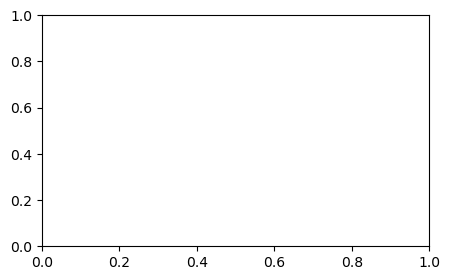

In [ ]:
fig, ax = plt.subplots(figsize=(5, 3)) #set size of figure to 5 x 3 inches
#note how this creates an empty figure and axes object, but with no data plotted

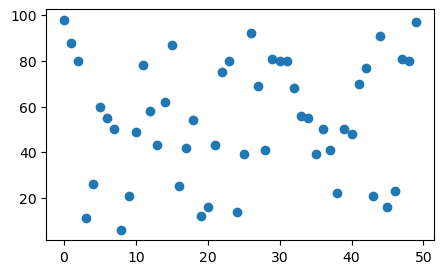

In [ ]:
#first create a scatterplot with this data
fig, ax = plt.subplots(figsize=(5, 3)) #set size of figure to 5 x 3 inches
ax.scatter(x,y) #apply function .scatter() on ax, as we are plotting the data inside ax and not inside fig
fig.show() #optional for Jupyter notebook as figures are automatically shown, but necessary for a standard python (.py) file

<BarContainer object of 50 artists>

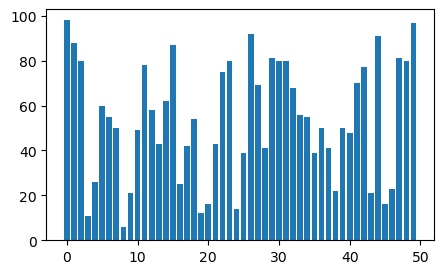

In [ ]:
#To recreate the figure as a bar graph
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(x,y)

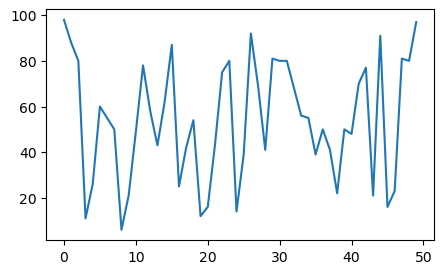

In [16]:
#alternatively, to make a line plot 
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y)

(array([4., 6., 2., 5., 7., 6., 4., 3., 9., 4.]),
 array([ 6. , 15.2, 24.4, 33.6, 42.8, 52. , 61.2, 70.4, 79.6, 88.8, 98. ]),
 <BarContainer object of 10 artists>)

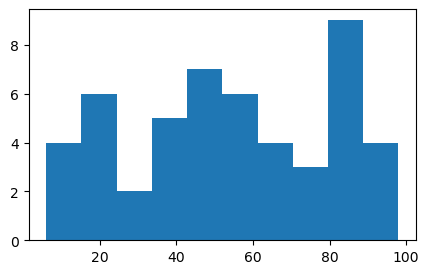

In [24]:
#ACTIVITY: create a histogram with this data
fig, ax = plt.subplots(figsize=(5,3))
ax.hist(y) #note histogram only needs the y values, not the x values

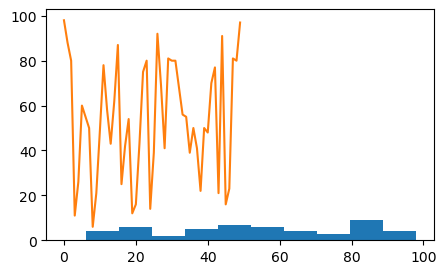

In [33]:
fig, ax = plt.subplots(figsize=(5, 3)) #note you have to rerun this line every time. since each time you run ax.<plot type> function, it modifies the ax variable to represent the plot type
#see what happens if you run two ax.<plot type> functions back to back without 'resetting' ax: 
ax.hist(y)
ax.plot(x,y)

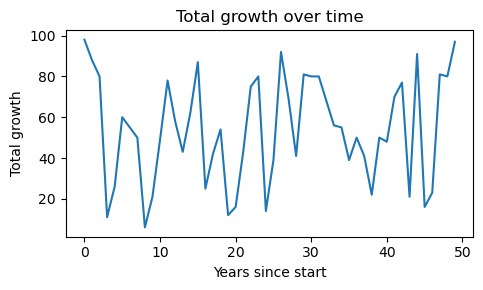

In [ ]:
#now add plot labels 
fig, ax = plt.subplots(figsize=(5,3))

ax.set_title('Total growth over time')
ax.set_ylabel('Total growth')
ax.set_xlabel('Years since start')
fig.tight_layout() #for cleaner display. 

ax.plot(y)

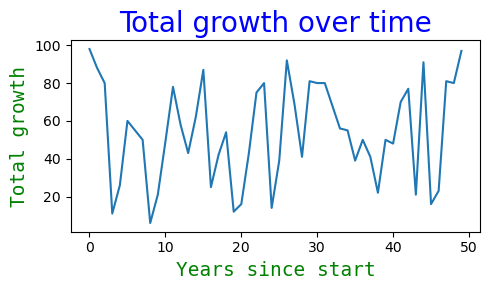

In [35]:
#can customize fonts, font size, font color of labels 
font1 = {'family':'sans-serif', 'color':'blue', 'size':20}
font2 = {'family':'monospace', 'color':'green', 'size':14}

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y)
ax.set_title('Total growth over time', fontdict = font1)
ax.set_ylabel('Total growth', fontdict = font2)
ax.set_xlabel('Years since start', fontdict = font2)
fig.tight_layout()

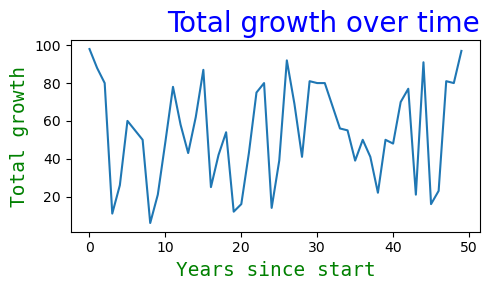

In [36]:
#labels can be moved around with the loc function
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,y)
ax.set_title('Total growth over time', fontdict = font1, loc='right')
ax.set_ylabel('Total growth', fontdict = font2)
ax.set_xlabel('Years since start', fontdict = font2)
fig.tight_layout()

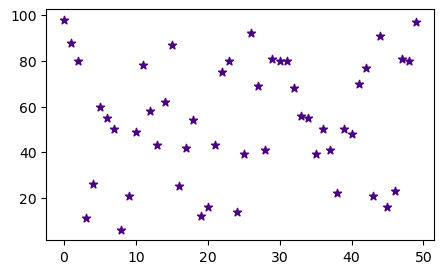

In [ ]:
#change the shape and color of data points 
fig, ax = plt.subplots(figsize=(5,3))
ax.scatter(x,y,marker='*',color='indigo') 

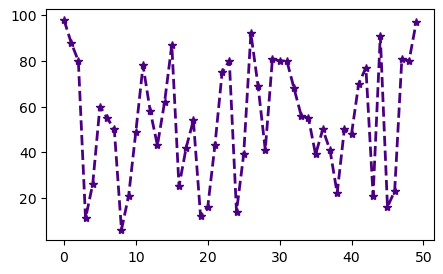

In [ ]:
#for line plots, can change the width and style of the line 
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,
        y, 
        marker="*", 
        color="indigo", 
        linestyle='--', 
        linewidth=2)

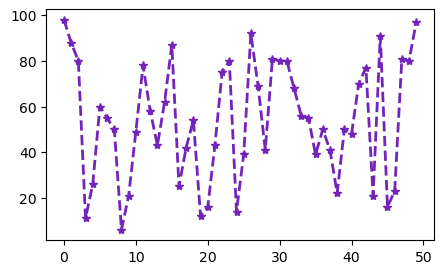

In [ ]:
#colors can be called by name or by hex code 
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x,
        y, 
        marker="*", 
        color="#7425b9", #a lighter shade of purple 
        linestyle='--', 
        linewidth=2)

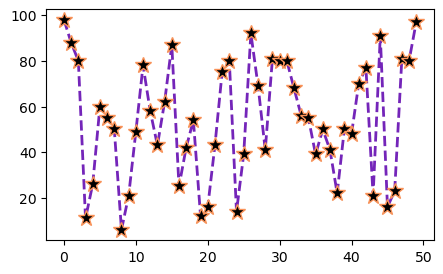

In [47]:
#additional specs for marker size, marker edge color, marker face color
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(x, 
        y, 
        marker="*", 
        markersize=12, 
        markeredgecolor = "#fa9359", 
        markerfacecolor = "#000000",
        color="#7425b9", 
        linestyle="--", 
        linewidth=2
        )

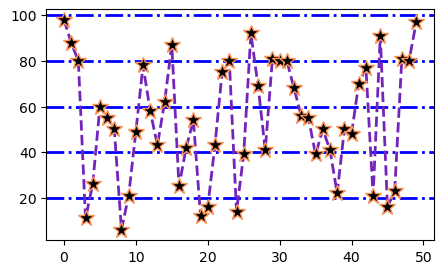

In [49]:
#modifying grid lines 
fig, ax = plt.subplots(figsize=(5,3))
ax.grid(axis='y', color='blue', linewidth=2, linestyle="-.")
ax.plot(x, 
        y, 
        marker="*", 
        markersize=12, 
        markeredgecolor = "#fa9359", 
        markerfacecolor = "#000000",
        color="#7425b9", 
        linestyle="--", 
        linewidth=2
        )

# Activity in 02_getting_started_matplotlib, slide 31

- Select a visualization from https://python-graph-gallery.com/all-charts/ 
- Replicate it in Python
- Comment on its aesthetic, substantive and perceptual qualities 

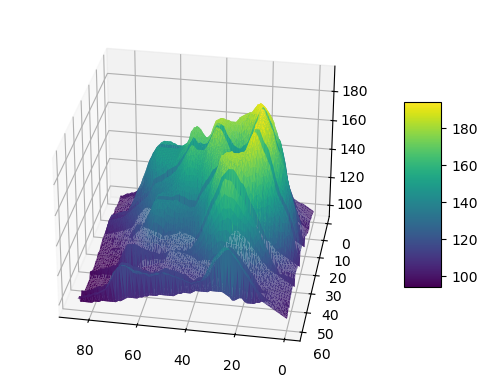

In [11]:
# Import necessary libraries
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Get the data (csv file is hosted on the web)
url = 'https://raw.githubusercontent.com/holtzy/The-Python-Graph-Gallery/master/static/data/volcano.csv'
data = pd.read_csv(url)

# Transform it to a long format
df = data.unstack().reset_index()
df.columns = ["X", "Y", "Z"]

# Transform the old column name in something numeric
df['X'] = pd.Categorical(df['X'])
df['X'] = df['X'].cat.codes

# Create the plot
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

# Plot the data
trisurf = ax.plot_trisurf(df['Y'], df['X'], df['Z'], cmap=plt.cm.viridis, linewidth=0.2)

# Set the angle of the camera
ax.view_init(30, 100)

# Add color bar which maps values to colors
fig.colorbar(trisurf, ax=ax, shrink=0.5, aspect=5)

# Show the plot
plt.show()

I chose the 3D density plot from https://python-graph-gallery.com/342-animation-on-3d-plot/. The plot is meant to be able to be animated such that it rotates, but would require exporting a gif (as VS Code cannot natively display the animation), so I have only included the code for displaying the unanimated plot above. 

Is this plot aesthetic? yes, it is visually pleasing to look at with the the colors and 3D nature. 
Is the plot substantive? yes, it presents data neutrally and clearly. In order to avoid bias it can be animated to rotate, or fixed at any angle of choice, so that all faces of the density plot can be seen by the viewer (if the view is fixed to a certain angle there would be bias in terms of which part of the contour you can and cannot see.)
Is the plot perceptual? yes, if given axes titles it would be easy to understand the takeaway of the data, as the layout is relatively simple, and the colors and axes are easily interpretable. 